# Devanagari Handwriting Recognition — Two-Phase CRNN
## VGG16 + BiLSTM + CTC  |  Hindi Pre-training → Nepali Fine-tuning

**Architecture summary**
- Backbone: VGG16 (pretrained ImageNet), blocks 4–5 use asymmetric pooling `(2,1)` to preserve temporal width for CTC
- Sequence model: 2-layer Bidirectional LSTM, hidden=256
- Loss: CTC (blank=0)
- Input resolution: **320 × 128** → 40 timesteps after pooling
- Phase 1: Hindi handwriting (~92k images, pre-split CSVs)
- Phase 2: Nepali font-generated images (~24k words × 18 font variants, random per epoch)
- Phase 3: NLP postprocessor (Levenshtein over vocab.json)

---


## 0 · Environment Setup

In [15]:
# Install required packages (Kaggle already has torch/torchvision)
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "python-Levenshtein", "-q"])

import os, json, random, warnings, time
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as T

import Levenshtein

print(f"PyTorch  : {torch.__version__}")
print(f"CUDA     : {torch.cuda.is_available()} | device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


PyTorch  : 2.10.0+cu128
CUDA     : True | device: Tesla T4


## 1 · Dataset Paths & Global Config

In [16]:
# ── Kaggle dataset roots ──────────────────────────────────────────────────────
# Hindi dataset:
#   CSVs live at:   dataset_root/   (train.csv, val.csv, test.csv)
#   Images live at: dataset_root/HindiSeg/HindiSeg/train|val|test/...
# CSV root = dataset root (train.csv / val.csv / test.csv live here directly)
# Img root = dataset_root/HindiSeg/HindiSeg/ (where the image folders are)
_hindi_csv_candidates = [
    Path('/kaggle/input/datasets/sabarinathan/handwritten-hindi-word-recognition'),
    Path('/kaggle/input/handwritten-hindi-word-recognition'),
]
HINDI_CSV_ROOT = next((p for p in _hindi_csv_candidates if (p / 'train.csv').exists()), _hindi_csv_candidates[0])
HINDI_IMG_ROOT = HINDI_CSV_ROOT / 'HindiSeg' / 'HindiSeg'

# Nepali dataset — probe multiple possible slug names
_nepali_candidates = [
    Path('/kaggle/input/datasets/kritakhere/nepali-font-generated-handwritten-names'),
    Path('/kaggle/input/nepali-font-generated-handwritten-names'),
    Path('/kaggle/input/nepali-font-generated-handwritten'),
]
NEPALI_ROOT = next((p for p in _nepali_candidates if p.exists()), _nepali_candidates[0])

# Vocab (NLP postprocessor) — probe multiple possible slug names
_vocab_candidates = [
    Path('/kaggle/input/datasets/nepali-names-shernames-districts/vocab.json'),
    Path('/kaggle/input/nepali-names-shernames-districts/vocab.json'),
    Path('/kaggle/input/nepali-names-surnames-districts/vocab.json'),
]
VOCAB_PATH = next((p for p in _vocab_candidates if p.exists()), _vocab_candidates[0])

# ── Output / checkpoint dirs ───────────────────────────────────────────────────
CKPT_P1 = Path('/kaggle/working/checkpoints/phase1');  CKPT_P1.mkdir(parents=True, exist_ok=True)
CKPT_P2 = Path('/kaggle/working/checkpoints/phase2');  CKPT_P2.mkdir(parents=True, exist_ok=True)
GRAPH_DIR = Path('/kaggle/working/graphs');             GRAPH_DIR.mkdir(parents=True, exist_ok=True)

# ── Model / training hyperparameters ──────────────────────────────────────────
IMG_W, IMG_H    = 320, 128          # fixed for both phases
BATCH_SIZE      = 64
BILSTM_HIDDEN   = 256
BILSTM_LAYERS   = 2
NUM_FONT_VARS   = 18                # font0 .. font17

# Phase 1
P1_MAX_EPOCHS   = 30
P1_LR_DEFAULT   = 1e-4
P1_ES_PATIENCE  = 5
P1_ES_WARN      = 3                 # warn at this many no-improve epochs
P1_DROPOUT_LSTM = 0.3
P1_DROPOUT_FC   = 0.3

# Phase 2
P2_MAX_EPOCHS   = 20
P2_LR_CNN_TAIL  = 1e-6
P2_LR_SEQ       = 1e-4
P2_ES_PATIENCE  = 5
P2_ES_WARN      = 3
P2_DROPOUT_LSTM = 0.4
P2_DROPOUT_FC   = 0.4

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

print("Paths and config loaded.")
print(f"  Hindi CSV root  : {HINDI_CSV_ROOT}")
print(f"  Hindi img root  : {HINDI_IMG_ROOT}")
print(f"  Nepali root     : {NEPALI_ROOT}")
print(f"  Vocab           : {VOCAB_PATH}")

# Quick sanity check — fail loud if paths don't exist
for p, label in [(HINDI_CSV_ROOT, 'Hindi CSV root'),
                 (HINDI_IMG_ROOT, 'Hindi img root (HindiSeg/HindiSeg)'),
                 (NEPALI_ROOT,    'Nepali root')]:
    assert p.exists(), f"PATH NOT FOUND: {label} → {p}"
    print(f"  ✓ {label}")


Paths and config loaded.
  Hindi CSV root  : /kaggle/input/datasets/sabarinathan/handwritten-hindi-word-recognition
  Hindi img root  : /kaggle/input/datasets/sabarinathan/handwritten-hindi-word-recognition/HindiSeg/HindiSeg
  Nepali root     : /kaggle/input/datasets/kritakhere/nepali-font-generated-handwritten-names
  Vocab           : /kaggle/input/datasets/nepali-names-shernames-districts/vocab.json
  ✓ Hindi CSV root
  ✓ Hindi img root (HindiSeg/HindiSeg)
  ✓ Nepali root


## 2 · Vocabulary Builder

Vocabulary is built from Phase 1 labels, then **extended** (never replaced) with any new characters found in Phase 2 labels. This keeps CTC alignment stable across phases.

In [18]:
class Vocabulary:
    """Character-level vocabulary with CTC blank at index 0."""
    BLANK = 0

    def __init__(self):
        self.char2idx = {'<BLANK>': 0}
        self.idx2char = {0: '<BLANK>'}

    def build_from_labels(self, labels):
        """Add any unseen characters from an iterable of label strings."""
        new_chars = sorted(set(ch for lbl in labels for ch in lbl) - set(self.char2idx))
        for ch in new_chars:
            idx = len(self.char2idx)
            self.char2idx[ch] = idx
            self.idx2char[idx] = ch
        return len(new_chars)

    def encode(self, text):
        return [self.char2idx[ch] for ch in text if ch in self.char2idx]

    def decode(self, indices):
        return ''.join(self.idx2char.get(i, '') for i in indices if i != self.BLANK)

    def __len__(self):
        return len(self.char2idx)

vocab = Vocabulary()
print("Vocabulary initialised (blank at index 0). Characters will be added when labels are loaded.")


Vocabulary initialised (blank at index 0). Characters will be added when labels are loaded.


## 3 · Phase 1 — Hindi Dataset

Loads from pre-split `train.csv`, `val.csv`, `test.csv`. Each CSV has columns `file_name` (relative path inside `HindiSeg/`) and `text` (Devanagari label).

In [19]:
def load_hindi_csv(split: str, csv_root: Path, img_root: Path) -> pd.DataFrame:
    """Read a split CSV and return a dataframe with absolute image paths and labels.
    
    The CSV lives in csv_root (HindiSeg/).
    The file_name column contains paths like 'HindiSeg/train/1/102/1.jpg'
    which are relative to csv_root's parent — but we strip the leading 'HindiSeg/'
    and resolve against img_root (HindiSeg/HindiSeg/) instead.
    """
    csv_path = csv_root / f'{split}.csv'
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip().str.lower()
    df = df.rename(columns={'file_name': 'path', 'text': 'label'})

    def resolve_path(p):
        p = str(p).strip()
        # CSV paths look like 'HindiSeg/train/8/251/21.jpg'
        # Strip the leading 'HindiSeg/' prefix if present so we get 'train/8/251/21.jpg'
        # then join with img_root which IS the inner HindiSeg/HindiSeg folder
        parts = Path(p).parts
        if parts and parts[0].lower() == 'hindiseg':
            p = str(Path(*parts[1:]))
        return str(img_root / p)

    df['path'] = df['path'].apply(resolve_path)
    df = df.dropna(subset=['label'])
    df['label'] = df['label'].astype(str).str.strip()
    df = df[df['label'].str.len() > 0]
    return df.reset_index(drop=True)

hindi_train = load_hindi_csv('train', HINDI_CSV_ROOT, HINDI_IMG_ROOT)
hindi_val   = load_hindi_csv('val',   HINDI_CSV_ROOT, HINDI_IMG_ROOT)
hindi_test  = load_hindi_csv('test',  HINDI_CSV_ROOT, HINDI_IMG_ROOT)

print(f"Hindi split sizes  →  train: {len(hindi_train):,}  |  val: {len(hindi_val):,}  |  test: {len(hindi_test):,}")
print(f"Sample path : {hindi_train.iloc[0]['path']}")
print(f"Sample label: {hindi_train.iloc[0]['label']}")

# Verify first image actually exists on disk
first_path = Path(hindi_train.iloc[0]['path'])
print(f"First image exists: {first_path.exists()}  ({'✓' if first_path.exists() else '✗ CHECK PATH'})")

# Build vocabulary from all split labels
n_new = vocab.build_from_labels(hindi_train['label'].tolist()
                                + hindi_val['label'].tolist()
                                + hindi_test['label'].tolist())
print(f"\nVocabulary size after Hindi labels: {len(vocab)}  (added {n_new} characters)")


Hindi split sizes  →  train: 69,853  |  val: 12,708  |  test: 12,869
Sample path : /kaggle/input/datasets/sabarinathan/handwritten-hindi-word-recognition/HindiSeg/HindiSeg/train/8/251/21.jpg
Sample label: केंद्रों
First image exists: True  (✓)

Vocabulary size after Hindi labels: 109  (added 108 characters)


## 4 · Phase 2 — Nepali Dataset

**Key design decision:** The dataset is split on **word IDs**, not individual files. This prevents data leakage where font3 of a word appears in train while font11 appears in val.

At each epoch, for every word ID in the split, **one font variant is chosen at random** from all available `font0..font17` files. This acts as implicit augmentation without any geometric transforms (fonts are already clean).

In [20]:
def load_nepali_labels(root: Path) -> dict:
    """Parse labels.txt → {word_id_str: label_text}. 
    Expected format: one entry per line, 'wordNNNNN <label>' or 'wordNNNNN_fontX <label>'.
    We normalise to word ID only (strip font suffix if present).
    """
    label_map = {}
    lbl_file = root / 'labels.txt'
    with open(lbl_file, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line: continue
            parts = line.split(None, 1)
            if len(parts) != 2: continue
            key, text = parts
            # Normalise: 'word00000_font0' -> 'word00000'
            word_id = key.split('_font')[0].replace('.png','').replace('.jpg','')
            label_map[word_id] = text.strip()
    return label_map

def scan_nepali_images(root: Path, label_map: dict) -> dict:
    """For each word_id in label_map, collect all available font variant paths.
    Returns {word_id: [path_font0, path_font1, ...]} with only existing files.
    """
    img_dir = root / 'images'
    word_to_fonts = {}
    for word_id in label_map:
        paths = []
        for fid in range(NUM_FONT_VARS):   # 0..17
            for ext in ['.png', '.jpg']:
                p = img_dir / f'{word_id}_font{fid}{ext}'
                if p.exists():
                    paths.append(str(p))
                    break
        if paths:
            word_to_fonts[word_id] = paths
    return word_to_fonts

nepali_label_map  = load_nepali_labels(NEPALI_ROOT)
nepali_word_fonts = scan_nepali_images(NEPALI_ROOT, nepali_label_map)

print(f"Nepali words with labels    : {len(nepali_label_map):,}")
print(f"Nepali words with images    : {len(nepali_word_fonts):,}")
total_imgs = sum(len(v) for v in nepali_word_fonts.values())
print(f"Total font-variant images   : {total_imgs:,}")
avg_fonts = total_imgs / max(len(nepali_word_fonts), 1)
print(f"Avg font variants per word  : {avg_fonts:.1f}")

# Split word IDs (not files) → 75 / 16 / 9  train/val/test
word_ids = sorted(nepali_word_fonts.keys())
random.seed(42)
random.shuffle(word_ids)
n = len(word_ids)
n_train = int(0.75 * n)
n_val   = int(0.16 * n)
nep_train_ids = word_ids[:n_train]
nep_val_ids   = word_ids[n_train:n_train + n_val]
nep_test_ids  = word_ids[n_train + n_val:]
print(f"\nNepali word-ID split  →  train: {len(nep_train_ids):,}  |  val: {len(nep_val_ids):,}  |  test: {len(nep_test_ids):,}")

# Extend vocabulary with any Nepali-only characters
n_new = vocab.build_from_labels([nepali_label_map[wid] for wid in word_ids])
print(f"Vocabulary size after Nepali extension: {len(vocab)}  (added {n_new} new characters)")


Nepali words with labels    : 1,358
Nepali words with images    : 1,358
Total font-variant images   : 24,444
Avg font variants per word  : 18.0

Nepali word-ID split  →  train: 1,018  |  val: 217  |  test: 123
Vocabulary size after Nepali extension: 117  (added 8 new characters)


## 5 · Dataset & DataLoader Classes

In [21]:
# ── Transforms ────────────────────────────────────────────────────────────────
def make_transform(augment: bool = False):
    ops = [T.Resize((IMG_H, IMG_W))]
    if augment:
        ops += [
            T.RandomRotation(degrees=5, fill=255),
            T.ColorJitter(brightness=0.3, contrast=0.3),
            T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5)),
        ]
    ops += [
        T.Grayscale(num_output_channels=3),   # VGG16 expects 3 channels
        T.ToTensor(),
        T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]
    return T.Compose(ops)

# ── Hindi Dataset ──────────────────────────────────────────────────────────────
class HindiDataset(Dataset):
    def __init__(self, df: pd.DataFrame, vocab: Vocabulary, augment: bool = False):
        self.df        = df.reset_index(drop=True)
        self.vocab     = vocab
        self.transform = make_transform(augment)

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(row['path']).convert('RGB')
        image = self.transform(image)
        label = torch.tensor(self.vocab.encode(row['label']), dtype=torch.long)
        return image, label

# ── Nepali Dataset (per-epoch font randomization) ─────────────────────────────
class NepaliDataset(Dataset):
    """
    One sample = one word ID. On each __getitem__ call a random font variant
    is selected, giving different renderings across epochs automatically.
    Call dataset.resample() at the start of each epoch to re-roll selections
    (optional but makes behaviour explicit and reproducible with seeding).
    """
    def __init__(self, word_ids: list, word_to_fonts: dict,
                 label_map: dict, vocab: Vocabulary, augment: bool = False):
        self.word_ids     = word_ids
        self.word_to_fonts = word_to_fonts
        self.label_map    = label_map
        self.vocab        = vocab
        self.transform    = make_transform(augment)
        self.resample()   # draw initial font selection

    def resample(self):
        """Re-roll font choice for every word. Call once per epoch in training loop."""
        self.selected_paths = {
            wid: random.choice(self.word_to_fonts[wid])
            for wid in self.word_ids
        }

    def __len__(self): return len(self.word_ids)

    def __getitem__(self, idx):
        wid   = self.word_ids[idx]
        path  = self.selected_paths[wid]
        image = Image.open(path).convert('RGB')
        image = self.transform(image)
        label = torch.tensor(self.vocab.encode(self.label_map[wid]), dtype=torch.long)
        return image, label

# ── CTC Collate ───────────────────────────────────────────────────────────────
def ctc_collate(batch):
    """Pad images to same width; pack variable-length labels for CTCLoss."""
    images, labels = zip(*batch)
    images  = torch.stack(images)                            # [B, 3, H, W]
    lengths = torch.tensor([len(l) for l in labels])
    targets = torch.cat(labels)                              # flat concat for CTC
    return images, targets, lengths

# ── Instantiate datasets ───────────────────────────────────────────────────────
ds_h_train = HindiDataset(hindi_train, vocab, augment=True)
ds_h_val   = HindiDataset(hindi_val,   vocab, augment=False)
ds_h_test  = HindiDataset(hindi_test,  vocab, augment=False)

ds_n_train = NepaliDataset(nep_train_ids, nepali_word_fonts, nepali_label_map, vocab, augment=True)
ds_n_val   = NepaliDataset(nep_val_ids,   nepali_word_fonts, nepali_label_map, vocab, augment=False)
ds_n_test  = NepaliDataset(nep_test_ids,  nepali_word_fonts, nepali_label_map, vocab, augment=False)

dl_h_train = DataLoader(ds_h_train, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=ctc_collate, num_workers=4, pin_memory=True)
dl_h_val   = DataLoader(ds_h_val,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=ctc_collate, num_workers=4, pin_memory=True)
dl_h_test  = DataLoader(ds_h_test,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=ctc_collate, num_workers=4, pin_memory=True)

dl_n_train = DataLoader(ds_n_train, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=ctc_collate, num_workers=4, pin_memory=True)
dl_n_val   = DataLoader(ds_n_val,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=ctc_collate, num_workers=4, pin_memory=True)
dl_n_test  = DataLoader(ds_n_test,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=ctc_collate, num_workers=4, pin_memory=True)

print("Datasets and DataLoaders ready.")
print(f"  Hindi   train/val/test batches : {len(dl_h_train)} / {len(dl_h_val)} / {len(dl_h_test)}")
print(f"  Nepali  train/val/test batches : {len(dl_n_train)} / {len(dl_n_val)} / {len(dl_n_test)}")


Datasets and DataLoaders ready.
  Hindi   train/val/test batches : 1092 / 199 / 202
  Nepali  train/val/test batches : 16 / 4 / 2


## 6 · Model Architecture — CRNN with Asymmetric Pooling

The critical change from stock VGG16 is replacing MaxPool2d `(2,2)` in **blocks 4 and 5** with `(2,1)` — pooling height but **not width**. This preserves temporal resolution for CTC.

| Resolution | Standard pools (÷32) | Asymmetric pools (÷8) |
|---|---|---|
| 320 px wide | 10 timesteps | **40 timesteps** |

40 timesteps for 6–8 Devanagari characters is comfortable for CTC decoding conjuncts and matras.


In [22]:
class CRNNDevanagari(nn.Module):
    def __init__(self, num_classes: int, lstm_dropout: float = 0.3, fc_dropout: float = 0.3):
        super().__init__()

        # ── Load pretrained VGG16 ─────────────────────────────────────────────
        vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        features = list(vgg.features.children())   # 31 layers indexed 0-30

        # ── Identify the two pooling layers in blocks 4 & 5 ──────────────────
        # Block 4 pool → features[23]  (after layers 17,18,19,20,21,22)
        # Block 5 pool → features[30]  (after layers 24,25,26,27,28,29)
        for idx in [23, 30]:
            features[idx] = nn.MaxPool2d(kernel_size=(2, 1), stride=(2, 1))

        self.cnn = nn.Sequential(*features)

        # ── Collapse remaining height to 1 ───────────────────────────────────
        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, None))

        # ── BiLSTM sequence model ─────────────────────────────────────────────
        self.bilstm = nn.LSTM(
            input_size  = 512,
            hidden_size = BILSTM_HIDDEN,
            num_layers  = BILSTM_LAYERS,
            bidirectional = True,
            dropout     = lstm_dropout,
            batch_first = False
        )

        # ── FC head ───────────────────────────────────────────────────────────
        self.fc_drop = nn.Dropout(fc_dropout)
        self.fc      = nn.Linear(BILSTM_HIDDEN * 2, num_classes)

    def forward(self, x):
        # x: [B, 3, 128, 320]
        feat = self.cnn(x)                     # [B, 512, 4, 40]
        feat = self.adaptive_pool(feat)        # [B, 512, 1, 40]
        feat = feat.squeeze(2)                 # [B, 512, 40]
        feat = feat.permute(2, 0, 1)           # [40, B, 512]  ← T, B, C for LSTM
        out, _ = self.bilstm(feat)             # [40, B, 512]
        out  = self.fc_drop(out)
        out  = self.fc(out)                    # [40, B, num_classes]
        out  = out.log_softmax(2)              # required by CTCLoss
        return out                             # [T, B, C]

def build_model(num_classes, lstm_drop=P1_DROPOUT_LSTM, fc_drop=P1_DROPOUT_FC):
    model = CRNNDevanagari(num_classes, lstm_dropout=lstm_drop, fc_dropout=fc_drop)
    return model.to(DEVICE)

# Quick shape test
_m = build_model(len(vocab))
_x = torch.randn(2, 3, IMG_H, IMG_W).to(DEVICE)
_o = _m(_x)
print(f"Output shape: {_o.shape}   (expected: [40, 2, {len(vocab)}])")
assert _o.shape == (40, 2, len(vocab)), "Shape mismatch — check asymmetric pool layers"
print("Model architecture verified ✓")
del _m, _x, _o


Output shape: torch.Size([40, 2, 117])   (expected: [40, 2, 117])
Model architecture verified ✓


## 7 · Layer Freezing Utilities

In [25]:
def freeze_vgg_blocks(model: CRNNDevanagari, blocks: list):
    """Freeze named VGG16 blocks. blocks is a list of integers 1-5.
    Block mapping:
        Block 1 : features[0:5]   (conv layers 0,2)
        Block 2 : features[5:10]  (conv layers 5,7)
        Block 3 : features[10:17] (conv layers 10,12,14)
        Block 4 : features[17:24] (conv layers 17,19,21)
        Block 5 : features[24:31] (conv layers 24,26,28)
    """
    BLOCK_RANGES = {
        1: range(0,  5),
        2: range(5,  10),
        3: range(10, 17),
        4: range(17, 24),
        5: range(24, 31),
    }
    for b in blocks:
        for idx in BLOCK_RANGES[b]:
            layer = model.cnn[idx]
            for p in layer.parameters():
                p.requires_grad = False
    frozen = [b for b in blocks]
    print(f"Frozen VGG16 blocks: {frozen}")

def freeze_block4_partial(model: CRNNDevanagari):
    """Freeze only the first two conv layers of block 4 (layers 17 and 19).
    Layer 21 (block 4 conv 3) remains trainable at low LR.
    """
    for idx in [17, 18, 19, 20]:   # conv17 + relu18, conv19 + relu20
        for p in model.cnn[idx].parameters():
            p.requires_grad = False
    print("Frozen block 4 conv1+conv2 (layers 17-20). Layer 21+ trainable.")

def count_params(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Parameters  →  total: {total:,}  |  trainable: {trainable:,}  |  frozen: {total-trainable:,}")
    return trainable


## 8 · Metrics & CTC Decoder

In [26]:
def ctc_greedy_decode(log_probs: torch.Tensor, vocab: Vocabulary) -> list:
    """
    Greedy CTC decode: argmax over class dim, collapse repeats, remove blanks.
    log_probs: [T, B, C]
    Returns list of decoded strings (length B).
    """
    pred_indices = log_probs.argmax(2)   # [T, B]
    pred_indices = pred_indices.permute(1, 0).cpu().numpy()   # [B, T]
    decoded = []
    for seq in pred_indices:
        chars = []
        prev  = -1
        for idx in seq:
            if idx != prev and idx != vocab.BLANK:
                chars.append(vocab.idx2char.get(int(idx), ''))
            prev = idx
        decoded.append(''.join(chars))
    return decoded

def compute_cer(predictions: list, targets: list) -> float:
    """Character Error Rate = mean edit distance / target length (capped at 1.0)."""
    cers = []
    for pred, tgt in zip(predictions, targets):
        if len(tgt) == 0:
            cers.append(0.0 if len(pred) == 0 else 1.0)
        else:
            cer = min(Levenshtein.distance(pred, tgt) / len(tgt), 1.0)
            cers.append(cer)
    return float(np.mean(cers))

def compute_word_accuracy(predictions: list, targets: list) -> float:
    """Exact-match word accuracy."""
    return float(np.mean([p == t for p, t in zip(predictions, targets)]))


## 9 · Training & Evaluation Loop Utilities

In [27]:
ctc_loss_fn = nn.CTCLoss(blank=vocab.BLANK, reduction='mean', zero_infinity=True)

def run_epoch(model, loader, optimizer=None, is_train=True, vocab=vocab):
    """Run one epoch. Returns (avg_loss, cer, word_acc, all_preds, all_targets)."""
    model.train() if is_train else model.eval()
    total_loss, n_batches = 0.0, 0
    all_preds, all_targets = [], []

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for images, targets_flat, target_lengths in loader:
            images        = images.to(DEVICE)
            targets_flat  = targets_flat.to(DEVICE)
            target_lengths = target_lengths.to(DEVICE)

            log_probs = model(images)             # [T, B, C]
            T, B, _   = log_probs.shape
            input_lengths = torch.full((B,), T, dtype=torch.long, device=DEVICE)

            loss = ctc_loss_fn(log_probs, targets_flat, input_lengths, target_lengths)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()

            total_loss += loss.item()
            n_batches  += 1

            # Decode for metrics
            preds = ctc_greedy_decode(log_probs.detach(), vocab)
            # Reconstruct target strings from flat tensor + lengths
            offset = 0
            for i, length in enumerate(target_lengths.cpu().numpy()):
                tgt_seq = targets_flat[offset:offset+length].cpu().numpy()
                all_targets.append(vocab.decode(tgt_seq))
                offset += length
            all_preds.extend(preds)

    avg_loss = total_loss / max(n_batches, 1)
    cer      = compute_cer(all_preds, all_targets)
    wacc     = compute_word_accuracy(all_preds, all_targets)
    return avg_loss, cer, wacc, all_preds, all_targets


class EarlyStopping:
    """Monitors val loss; warns before stopping; saves best model."""
    def __init__(self, patience: int, warn_at: int, min_delta: float = 1e-4,
                 ckpt_dir: Path = None, phase_name: str = 'phase'):
        self.patience   = patience
        self.warn_at    = warn_at
        self.min_delta  = min_delta
        self.ckpt_dir   = ckpt_dir
        self.phase_name = phase_name
        self.best_loss  = float('inf')
        self.counter    = 0
        self.best_path  = None

    def step(self, val_loss: float, model, epoch: int, cer: float, wacc: float) -> str:
        """
        Returns: 'improve' | 'warn' | 'stop'
        Also saves checkpoint on every call; saves 'best' model when improved.
        """
        # ── Always save epoch checkpoint ──────────────────────────────────────
        ck_name = f'{self.phase_name}_epoch{epoch:03d}_wacc{wacc:.3f}_cer{cer:.4f}.pth'
        ck_path = self.ckpt_dir / ck_name
        torch.save({'epoch': epoch, 'model_state': model.state_dict(),
                    'val_loss': val_loss, 'cer': cer, 'word_acc': wacc}, ck_path)

        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter   = 0
            # Save best separately
            best_path = self.ckpt_dir / f'{self.phase_name}_BEST.pth'
            torch.save({'epoch': epoch, 'model_state': model.state_dict(),
                        'val_loss': val_loss, 'cer': cer, 'word_acc': wacc}, best_path)
            self.best_path = str(best_path)
            return 'improve'
        else:
            self.counter += 1
            if self.counter >= self.patience:
                return 'stop'
            elif self.counter >= self.warn_at:
                return 'warn'
            return 'no_improve'

    def load_best(self, model):
        if self.best_path and Path(self.best_path).exists():
            ckpt = torch.load(self.best_path, map_location=DEVICE)
            model.load_state_dict(ckpt['model_state'])
            print(f"  Loaded best checkpoint: {self.best_path}  (epoch {ckpt['epoch']}, val_loss={ckpt['val_loss']:.4f})")
        else:
            print("  WARNING: best checkpoint not found.")

print("Training utilities ready.")


Training utilities ready.


## 10 · Plotting Utilities

In [28]:
def plot_training_curves(history: dict, phase: str, save_dir: Path):
    """Saves G1/G4 (loss), G2/G5 (CER), G3/G6 (word acc) for a given phase."""
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'{phase} Training Curves', fontsize=14, fontweight='bold')

    # Loss
    axes[0].plot(epochs, history['train_loss'], label='Train Loss', color='steelblue')
    axes[0].plot(epochs, history['val_loss'],   label='Val Loss',   color='tomato')
    axes[0].set_title('CTC Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()
    axes[0].grid(alpha=0.3)

    # CER
    axes[1].plot(epochs, history['val_cer'], color='darkorange', marker='o', markersize=3)
    axes[1].set_title('Val CER'); axes[1].set_xlabel('Epoch')
    axes[1].set_ylim(0, 1); axes[1].grid(alpha=0.3)

    # Word Accuracy
    axes[2].plot(epochs, history['val_wacc'], color='seagreen', marker='s', markersize=3)
    axes[2].set_title('Val Word Accuracy'); axes[2].set_xlabel('Epoch')
    axes[2].set_ylim(0, 1); axes[2].grid(alpha=0.3)

    plt.tight_layout()
    fname = save_dir / f'{phase.lower().replace(" ","_")}_curves.png'
    plt.savefig(fname, dpi=150); plt.show()
    print(f"Saved: {fname}")


def plot_confusion_matrix(preds: list, targets: list, save_dir: Path, title: str, top_n: int = 20):
    """Character-level confusion matrix for the top_n most confused pairs."""
    from collections import Counter
    confusion = Counter()
    for pred, tgt in zip(preds, targets):
        # Align character by character (simple zip — not edit-distance aligned)
        for p_ch, t_ch in zip(pred, tgt):
            if p_ch != t_ch:
                confusion[(t_ch, p_ch)] += 1

    if not confusion:
        print("No character confusions found (perfect predictions or empty)."); return

    top_pairs = confusion.most_common(top_n)
    true_chars  = sorted(set(t for (t, _), _ in top_pairs))
    pred_chars  = sorted(set(p for (_, p), _ in top_pairs))
    all_chars   = sorted(set(true_chars + pred_chars))
    n = len(all_chars)
    matrix = np.zeros((n, n), dtype=int)
    char_to_i = {ch: i for i, ch in enumerate(all_chars)}
    for (t, p), cnt in confusion.items():
        if t in char_to_i and p in char_to_i:
            matrix[char_to_i[t]][char_to_i[p]] += cnt

    fig, ax = plt.subplots(figsize=(max(8, n), max(6, n)))
    sns.heatmap(matrix, xticklabels=all_chars, yticklabels=all_chars,
                annot=True, fmt='d', cmap='Reds', ax=ax, linewidths=0.3)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'{title} — Character Confusion (top {top_n} confused chars)')
    plt.tight_layout()
    fname = save_dir / f'{title.lower().replace(" ","_")}_confusion.png'
    plt.savefig(fname, dpi=150); plt.show()
    print(f"Saved: {fname}")


def plot_phase_comparison(p1_wacc: float, p2_wacc: float, save_dir: Path):
    """Bar chart comparing Phase 1 vs Phase 2 word accuracy on Nepali test set."""
    fig, ax = plt.subplots(figsize=(6, 5))
    bars = ax.bar(['Phase 1\n(Hindi only)', 'Phase 2\n(+Nepali fine-tune)'],
                  [p1_wacc, p2_wacc], color=['steelblue', 'seagreen'], width=0.4)
    for bar, val in zip(bars, [p1_wacc, p2_wacc]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontweight='bold')
    ax.set_ylim(0, 1.1); ax.set_ylabel('Word Accuracy')
    ax.set_title('Transfer Learning Benefit\n(Nepali Test Set)')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    fname = save_dir / 'phase_comparison.png'
    plt.savefig(fname, dpi=150); plt.show()
    print(f"Saved: {fname}")

print("Plotting utilities ready.")


Plotting utilities ready.


---
# ═══════════════════════════════════════════════════════════
# PHASE 1 — Hindi Handwriting Pre-training
# ═══════════════════════════════════════════════════════════

**Objective:** Train the full CRNN on ~92k real Hindi handwriting images. All Devanagari stroke patterns, ligatures, and matras are learned here from diverse, noisy handwriting. This forms the foundation that Phase 2 will build upon.

**Freezing:** Blocks 1–2 only (pure edge/curve detectors from ImageNet). Blocks 3–5 + BiLSTM + FC all trainable at `1e-4`.

**Augmentation:** Rotation ±5°, brightness/contrast jitter, Gaussian blur, elastic-like distortion via random crops.


### Phase 1 · Model Initialization & Freezing

In [29]:
# Build model
model_p1 = build_model(len(vocab), lstm_drop=P1_DROPOUT_LSTM, fc_drop=P1_DROPOUT_FC)

# Freeze blocks 1 and 2 (ImageNet edge/curve detectors — nothing script-specific)
freeze_vgg_blocks(model_p1, blocks=[1, 2])

# Count trainable params
p1_trainable = count_params(model_p1)


Frozen VGG16 blocks: [1, 2]
Parameters  →  total: 17,928,629  |  trainable: 17,668,469  |  frozen: 260,160


### Phase 1 · Optimizer & Scheduler

In [30]:
optimizer_p1 = optim.AdamW(
    filter(lambda p: p.requires_grad, model_p1.parameters()),
    lr=P1_LR_DEFAULT, weight_decay=1e-4
)

scheduler_p1 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_p1, mode='min', patience=3, factor=0.5
)

early_stop_p1 = EarlyStopping(
    patience  = P1_ES_PATIENCE,
    warn_at   = P1_ES_WARN,
    ckpt_dir  = CKPT_P1,
    phase_name = 'phase1'
)

print(f"Optimizer: AdamW  |  Initial LR: {P1_LR_DEFAULT}")
print(f"Early stopping: patience={P1_ES_PATIENCE}, warn at {P1_ES_WARN} no-improve epochs")


Optimizer: AdamW  |  Initial LR: 0.0001
Early stopping: patience=5, warn at 3 no-improve epochs


### Phase 1 · Training Loop

In [ ]:
history_p1 = {'train_loss': [], 'val_loss': [], 'val_cer': [], 'val_wacc': []}

print("=" * 70)
print("PHASE 1 — HINDI HANDWRITING TRAINING")
print("=" * 70)

phase1_stop = False
for epoch in range(1, P1_MAX_EPOCHS + 1):
    t0 = time.time()

    # ── Train ──────────────────────────────────────────────────────────────────
    tr_loss, tr_cer, tr_wacc, _, _ = run_epoch(
        model_p1, dl_h_train, optimizer=optimizer_p1, is_train=True)

    # ── Validate ───────────────────────────────────────────────────────────────
    vl_loss, vl_cer, vl_wacc, _, _ = run_epoch(
        model_p1, dl_h_val, is_train=False)

    elapsed = time.time() - t0
    history_p1['train_loss'].append(tr_loss)
    history_p1['val_loss'].append(vl_loss)
    history_p1['val_cer'].append(vl_cer)
    history_p1['val_wacc'].append(vl_wacc)

    # ── LR scheduler ──────────────────────────────────────────────────────────
    scheduler_p1.step(vl_loss)

    # ── Early stopping ────────────────────────────────────────────────────────
    es_status = early_stop_p1.step(vl_loss, model_p1, epoch, vl_cer, vl_wacc)

    # ── Logging ───────────────────────────────────────────────────────────────
    status_icon = {'improve': '✓', 'warn': '⚠', 'stop': '✗', 'no_improve': '·'}.get(es_status, '·')
    print(f"[P1] Ep {epoch:03d}/{P1_MAX_EPOCHS}  {status_icon}  "
          f"| TrLoss={tr_loss:.4f}  VlLoss={vl_loss:.4f}  "
          f"| CER={vl_cer:.4f}  WordAcc={vl_wacc:.4f}  "
          f"| {elapsed:.0f}s")

    if es_status == 'warn':
        no_improve = early_stop_p1.counter
        remaining  = P1_ES_PATIENCE - no_improve
        print(f"  ⚠️  WARNING: No improvement for {no_improve} epochs. "
              f"Will stop in {remaining} more epoch(s) if no improvement.")

    if es_status == 'stop':
        print(f"  ✗  EARLY STOPPING triggered at epoch {epoch}. "
              f"Best val loss: {early_stop_p1.best_loss:.4f}")
        phase1_stop = True
        break

if not phase1_stop:
    print(f"\nCompleted all {P1_MAX_EPOCHS} epochs.")

print(f"\nBest Phase 1 model saved at: {early_stop_p1.best_path}")


In [31]:
import os, glob
from pathlib import Path

ckpts = sorted(glob.glob('/kaggle/working/checkpoints/phase1/*.pth'))
print(f"Found {len(ckpts)} checkpoints:\n")
for c in ckpts:
    size_mb = os.path.getsize(c) / 1e6
    print(f"  {Path(c).name}  ({size_mb:.1f} MB)")

def parse_cer(p):
    try: return float(Path(p).stem.split('_cer')[1])
    except: return float('inf')

best_path = min(ckpts, key=parse_cer)
print(f"\nBest checkpoint: {Path(best_path).name}")

Found 13 checkpoints:

  phase1_BEST.pth  (71.7 MB)
  phase1_epoch001_wacc0.443_cer0.1653.pth  (71.7 MB)
  phase1_epoch002_wacc0.510_cer0.1382.pth  (71.7 MB)
  phase1_epoch003_wacc0.553_cer0.1245.pth  (71.7 MB)
  phase1_epoch004_wacc0.581_cer0.1194.pth  (71.7 MB)
  phase1_epoch005_wacc0.575_cer0.1176.pth  (71.7 MB)
  phase1_epoch006_wacc0.529_cer0.1339.pth  (71.7 MB)
  phase1_epoch007_wacc0.580_cer0.1195.pth  (71.7 MB)
  phase1_epoch008_wacc0.604_cer0.1115.pth  (71.7 MB)
  phase1_epoch009_wacc0.644_cer0.0967.pth  (71.7 MB)
  phase1_epoch010_wacc0.644_cer0.0966.pth  (71.7 MB)
  phase1_epoch011_wacc0.631_cer0.1051.pth  (71.7 MB)
  phase1_epoch012_wacc0.650_cer0.0972.pth  (71.7 MB)

Best checkpoint: phase1_epoch010_wacc0.644_cer0.0966.pth


In [45]:
checkpoint = torch.load(best_path, map_location='cpu')
resumed_epoch = checkpoint['epoch']
print(f"Resuming from epoch {resumed_epoch}")
print(f"  val_loss : {checkpoint['val_loss']:.4f}")
print(f"  CER      : {checkpoint['cer']:.4f}")
print(f"  Word Acc : {checkpoint['word_acc']:.4f}")

N_GPUS = torch.cuda.device_count()
print(f"\nGPUs available: {N_GPUS}")
for i in range(N_GPUS):
    print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")

state = checkpoint['model_state']
if all(k.startswith('module.') for k in state.keys()):
    state = {k[7:]: v for k, v in state.items()}

model = build_model(len(vocab), lstm_drop=P1_DROPOUT_LSTM, fc_drop=P1_DROPOUT_FC)
model = model.to(DEVICE)
model.load_state_dict(state)
freeze_vgg_blocks(model, blocks=[1, 2])

# No DataParallel — CTC loss breaks with batch splitting across GPUs
# Both GPUs still utilized via PyTorch's internal CUDA stream scheduling
print(f"Training on: {torch.cuda.get_device_name(0)}")

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=P1_LR_DEFAULT * 0.5
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)
print(f"\nReady. Resuming from epoch {resumed_epoch + 1}")

Resuming from epoch 10
  val_loss : 0.4402
  CER      : 0.0966
  Word Acc : 0.6440

GPUs available: 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4
Frozen VGG16 blocks: [1, 2]
Training on: Tesla T4

Ready. Resuming from epoch 11


In [33]:
checkpoint = torch.load(best_path, map_location='cpu')
print("Keys in checkpoint:", list(checkpoint.keys()))

Keys in checkpoint: ['epoch', 'model_state', 'val_loss', 'cer', 'word_acc']


In [46]:
early_stopper = EarlyStopping(
    patience=P1_ES_PATIENCE,
    warn_at=P1_ES_PATIENCE - 2,
    min_delta=1e-4,
    ckpt_dir=CKPT_P1,
    phase_name='phase1_resumed'
)

early_stopper.best_loss = checkpoint['val_loss']
early_stopper.counter   = 2

history_p1_resumed = {'train_loss': [], 'val_loss': [], 'val_cer': [], 'val_wacc': []}

print('='*60)
print(f'PHASE 1 RESUMING — epoch {resumed_epoch+1} → {P1_MAX_EPOCHS}')
print('='*60)

for epoch in range(resumed_epoch + 1, P1_MAX_EPOCHS + 1):
    t0 = time.time()

    tr_loss, tr_cer, tr_wacc, _, _ = run_epoch(model, dl_h_train, optimizer=optimizer, is_train=True)
    vl_loss, vl_cer, vl_wacc, _, _ = run_epoch(model, dl_h_val, is_train=False)

    scheduler.step(vl_loss)
    elapsed = time.time() - t0

    history_p1_resumed['train_loss'].append(tr_loss)
    history_p1_resumed['val_loss'].append(vl_loss)
    history_p1_resumed['val_cer'].append(vl_cer)
    history_p1_resumed['val_wacc'].append(vl_wacc)

    es_status = early_stopper.step(vl_loss, model, epoch, vl_cer, vl_wacc)

    status_icon = {'improve': '✓', 'warn': '⚠', 'stop': '✗', 'no_improve': '·'}.get(es_status, '·')
    print(f"[P1] Ep {epoch:03d}/{P1_MAX_EPOCHS}  {status_icon}  "
          f"| TrLoss={tr_loss:.4f}  VlLoss={vl_loss:.4f}  "
          f"| CER={vl_cer:.4f}  WordAcc={vl_wacc:.4f}  "
          f"| {elapsed:.0f}s")

    if es_status == 'warn':
        remaining = P1_ES_PATIENCE - early_stopper.counter
        print(f"  ⚠️  No improvement for {early_stopper.counter} epochs. "
              f"Stops in {remaining} more epoch(s) if no improvement.")

    if es_status == 'stop':
        print(f"  ✗  EARLY STOPPING at epoch {epoch}. Best val loss: {early_stopper.best_loss:.4f}")
        break

print(f"\nPhase 1 resumed training complete. Best model at: {early_stopper.best_path}")

PHASE 1 RESUMING — epoch 11 → 30
[P1] Ep 011/30  ⚠  | TrLoss=0.0532  VlLoss=0.4953  | CER=0.1057  WordAcc=0.6136  | 675s
  ⚠️  No improvement for 3 epochs. Stops in 2 more epoch(s) if no improvement.
[P1] Ep 012/30  ⚠  | TrLoss=0.0463  VlLoss=0.4777  | CER=0.1019  WordAcc=0.6356  | 675s
  ⚠️  No improvement for 4 epochs. Stops in 1 more epoch(s) if no improvement.
[P1] Ep 013/30  ✗  | TrLoss=0.0417  VlLoss=0.5362  | CER=0.1101  WordAcc=0.6089  | 676s
  ✗  EARLY STOPPING at epoch 13. Best val loss: 0.4402

Phase 1 resumed training complete. Best model at: None


In [47]:
print(f"Best checkpoint: {best_path}")
import os
print(f"Exists: {os.path.exists(best_path)}")

# Load and verify
ck = torch.load(best_path, map_location='cpu')
print(f"Epoch: {ck['epoch']}")
print(f"val_loss: {ck['val_loss']:.4f}")
print(f"CER: {ck['cer']:.4f}")
print(f"Word Acc: {ck['word_acc']:.4f}")

Best checkpoint: /kaggle/working/checkpoints/phase1/phase1_epoch010_wacc0.644_cer0.0966.pth
Exists: True
Epoch: 10
val_loss: 0.4402
CER: 0.0966
Word Acc: 0.6440


In [42]:
import inspect
print(inspect.signature(run_epoch))

(model, loader, optimizer=None, is_train=True, vocab=<__main__.Vocabulary object at 0x7e404d438230>)


In [40]:
import inspect
print(inspect.signature(EarlyStopping.__init__))

(self, patience: int, warn_at: int, min_delta: float = 0.0001, ckpt_dir: pathlib.Path = None, phase_name: str = 'phase')


### Phase 1 · Training Curves

In [ ]:
plot_training_curves(history_p1, phase='Phase 1 (Hindi)', save_dir=GRAPH_DIR)


### Phase 1 · Test Set Evaluation (Hindi)

In [50]:
# Load best Phase 1 weights manually since early_stop_p1.best_path was lost
ckpt = torch.load(best_path, map_location=DEVICE)
model_p1.load_state_dict(ckpt['model_state'])
print(f"Loaded best Phase 1 weights — epoch {ckpt['epoch']}, val_loss={ckpt['val_loss']:.4f}")

# Run on Hindi test set
te_loss, te_cer, te_wacc, te_preds, te_targets = run_epoch(
    model_p1, dl_h_test, is_train=False)

print("=" * 50)
print("PHASE 1 — HINDI TEST RESULTS")
print("=" * 50)
print(f"  CTC Loss    : {te_loss:.4f}")
print(f"  CER         : {te_cer:.4f}  ({te_cer*100:.2f}%)")
print(f"  Word Acc    : {te_wacc:.4f}  ({te_wacc*100:.2f}%)")
print(f"  WER         : {1-te_wacc:.4f}  ({(1-te_wacc)*100:.2f}%)")
print("=" * 50)

print("\nSample predictions (first 10):")
print(f"{'Target':<20} {'Predicted':<20} {'Match'}")
print("-" * 50)
for tgt, pred in list(zip(te_targets, te_preds))[:10]:
    print(f"{tgt:<20} {pred:<20} {'✓' if tgt==pred else '✗'}")

Loaded best Phase 1 weights — epoch 10, val_loss=0.4402
PHASE 1 — HINDI TEST RESULTS
  CTC Loss    : 0.3979
  CER         : 0.0899  (8.99%)
  Word Acc    : 0.6731  (67.31%)
  WER         : 0.3269  (32.69%)

Sample predictions (first 10):
Target               Predicted            Match
--------------------------------------------------
अनाथों               अनाथों               ✓
इज्ज्त               इज्त                 ✗
देखना                देरनना               ✗
मृतका                मृनका                ✗
ऊर्ध्वगामी           ऊरध्वठामी            ✗
छक्कों               छक्कों               ✓
प्रतिभावान           प्रततशवान            ✗
पदार्थ               पदार्थ               ✓
उबालें               उबालों               ✗
बसर                  बसर                  ✓


### Phase 1 · Evaluate on Nepali Test Set (baseline before fine-tuning)

In [53]:
# Run Phase 1 model on Nepali test set — this is the BASELINE for transfer learning comparison
_, _, p1_nep_wacc, p1_nep_preds, p1_nep_targets = run_epoch(
    model_p1, dl_n_test, is_train=False)

print(f"Phase 1 model on Nepali test  →  Word Acc: {p1_nep_wacc:.4f}  ({p1_nep_wacc*100:.2f}%)")
print("(This is the baseline before Nepali fine-tuning — saved for comparison chart)")


Phase 1 model on Nepali test  →  Word Acc: 0.4715  (47.15%)
(This is the baseline before Nepali fine-tuning — saved for comparison chart)


---
# ═══════════════════════════════════════════════════════════
# PHASE 2 — Nepali Font Fine-tuning
# ═══════════════════════════════════════════════════════════

**Objective:** Adapt the Phase 1 model to Nepali Devanagari vocabulary using font-generated images. The font data is clean and homogeneous — the strategy is to freeze most of the CNN (preserving handwriting robustness earned in Phase 1) and fine-tune only the high-level feature layers at a very low learning rate.

**Freezing:**
- Blocks 1–2: ❄️ frozen (same as Phase 1)
- Block 3: ❄️ frozen (Phase 1 learned Devanagari stroke junctions — font data would weaken this)
- Block 4 conv1+conv2: ❄️ frozen (protect handwriting generalization)
- Block 4 conv3 + Block 5: 🔥 trainable at `1e-6` (nudge Nepali glyph vocabulary)
- BiLSTM + FC: 🔥 trainable at `1e-4`

**Font randomization:** Each word ID picks a random font variant at the start of every epoch. This prevents the model from memorizing specific font appearances.


### Phase 2 · Model Initialization from Phase 1 Checkpoint

In [55]:
# Build fresh model with Phase 2 dropout settings
model_p2 = build_model(len(vocab), lstm_drop=P2_DROPOUT_LSTM, fc_drop=P2_DROPOUT_FC)

# Load best Phase 1 weights — using best_path directly since early_stop_p1.best_path is None
ckpt = torch.load(best_path, map_location=DEVICE)
model_p2.load_state_dict(ckpt['model_state'])
print(f"Loaded Phase 1 weights (epoch {ckpt['epoch']}, val_loss={ckpt['val_loss']:.4f})")

# ── Apply Phase 2 freezing ─────────────────────────────────────────────────────
freeze_vgg_blocks(model_p2, blocks=[1, 2, 3])
freeze_block4_partial(model_p2)

p2_trainable = count_params(model_p2)

Loaded Phase 1 weights (epoch 10, val_loss=0.4402)
Frozen VGG16 blocks: [1, 2, 3]
Frozen block 4 conv1+conv2 (layers 17-20). Layer 21+ trainable.
Parameters  →  total: 17,928,629  |  trainable: 12,653,173  |  frozen: 5,275,456


### Phase 2 · Optimizer with Differential Learning Rates

In [57]:
# Two learning rates: very low for CNN tail, normal for sequence head
cnn_tail_params = []
for idx in [21, 22]:   # block 4 conv3 + relu
    cnn_tail_params += list(model_p2.cnn[idx].parameters())
for idx in range(24, 31):  # block 5
    cnn_tail_params += list(model_p2.cnn[idx].parameters())

seq_params = list(model_p2.bilstm.parameters()) + list(model_p2.fc.parameters())

optimizer_p2 = optim.AdamW([
    {'params': cnn_tail_params, 'lr': P2_LR_CNN_TAIL},
    {'params': seq_params,      'lr': P2_LR_SEQ},
], weight_decay=1e-4)

scheduler_p2 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_p2, mode='min', patience=3, factor=0.5)

early_stop_p2 = EarlyStopping(
    patience   = P2_ES_PATIENCE,
    warn_at    = P2_ES_WARN,
    ckpt_dir   = CKPT_P2,
    phase_name = 'phase2'
)

print(f"CNN tail LR : {P2_LR_CNN_TAIL}  (block 4 conv3 + block 5)")
print(f"Seq head LR : {P2_LR_SEQ}   (BiLSTM + FC)")


CNN tail LR : 1e-06  (block 4 conv3 + block 5)
Seq head LR : 0.0001   (BiLSTM + FC)


### Phase 2 · Training Loop

In [58]:
history_p2 = {'train_loss': [], 'val_loss': [], 'val_cer': [], 'val_wacc': []}

print("=" * 70)
print("PHASE 2 — NEPALI FONT FINE-TUNING")
print("=" * 70)

phase2_stop = False
for epoch in range(1, P2_MAX_EPOCHS + 1):
    t0 = time.time()

    # ── Resample font variants for this epoch ─────────────────────────────────
    ds_n_train.resample()
    ds_n_val.resample()

    # ── Train ──────────────────────────────────────────────────────────────────
    tr_loss, tr_cer, tr_wacc, _, _ = run_epoch(
        model_p2, dl_n_train, optimizer=optimizer_p2, is_train=True)

    # ── Validate ───────────────────────────────────────────────────────────────
    vl_loss, vl_cer, vl_wacc, _, _ = run_epoch(
        model_p2, dl_n_val, is_train=False)

    elapsed = time.time() - t0
    history_p2['train_loss'].append(tr_loss)
    history_p2['val_loss'].append(vl_loss)
    history_p2['val_cer'].append(vl_cer)
    history_p2['val_wacc'].append(vl_wacc)

    scheduler_p2.step(vl_loss)

    es_status = early_stop_p2.step(vl_loss, model_p2, epoch, vl_cer, vl_wacc)

    status_icon = {'improve': '✓', 'warn': '⚠', 'stop': '✗', 'no_improve': '·'}.get(es_status, '·')
    print(f"[P2] Ep {epoch:03d}/{P2_MAX_EPOCHS}  {status_icon}  "
          f"| TrLoss={tr_loss:.4f}  VlLoss={vl_loss:.4f}  "
          f"| CER={vl_cer:.4f}  WordAcc={vl_wacc:.4f}  "
          f"| {elapsed:.0f}s")

    if es_status == 'warn':
        no_improve = early_stop_p2.counter
        remaining  = P2_ES_PATIENCE - no_improve
        print(f"  ⚠️  WARNING: No improvement for {no_improve} epochs. "
              f"Will stop in {remaining} more epoch(s) if no improvement.")

    if es_status == 'stop':
        print(f"  ✗  EARLY STOPPING triggered at epoch {epoch}. "
              f"Best val loss: {early_stop_p2.best_loss:.4f}")
        phase2_stop = True
        break

if not phase2_stop:
    print(f"\nCompleted all {P2_MAX_EPOCHS} epochs.")

print(f"\nBest Phase 2 model saved at: {early_stop_p2.best_path}")


PHASE 2 — NEPALI FONT FINE-TUNING
[P2] Ep 001/20  ✓  | TrLoss=0.9659  VlLoss=0.6900  | CER=0.1372  WordAcc=0.5438  | 9s
[P2] Ep 002/20  ✓  | TrLoss=0.8658  VlLoss=0.5830  | CER=0.1142  WordAcc=0.5945  | 8s
[P2] Ep 003/20  ·  | TrLoss=0.8195  VlLoss=0.5885  | CER=0.1184  WordAcc=0.5853  | 10s
[P2] Ep 004/20  ·  | TrLoss=0.7367  VlLoss=0.5955  | CER=0.1174  WordAcc=0.5576  | 8s
[P2] Ep 005/20  ✓  | TrLoss=0.7039  VlLoss=0.5572  | CER=0.1069  WordAcc=0.6313  | 8s
[P2] Ep 006/20  ✓  | TrLoss=0.6702  VlLoss=0.4983  | CER=0.1067  WordAcc=0.6037  | 8s
[P2] Ep 007/20  ·  | TrLoss=0.6852  VlLoss=0.5003  | CER=0.1147  WordAcc=0.5853  | 8s
[P2] Ep 008/20  ✓  | TrLoss=0.5927  VlLoss=0.4735  | CER=0.0990  WordAcc=0.6083  | 8s
[P2] Ep 009/20  ✓  | TrLoss=0.6030  VlLoss=0.4163  | CER=0.1055  WordAcc=0.6037  | 8s
[P2] Ep 010/20  ·  | TrLoss=0.5791  VlLoss=0.4443  | CER=0.0946  WordAcc=0.6313  | 9s
[P2] Ep 011/20  ·  | TrLoss=0.5790  VlLoss=0.4753  | CER=0.1072  WordAcc=0.6083  | 8s
[P2] Ep 012/20  ⚠  

### Phase 2 · Training Curves

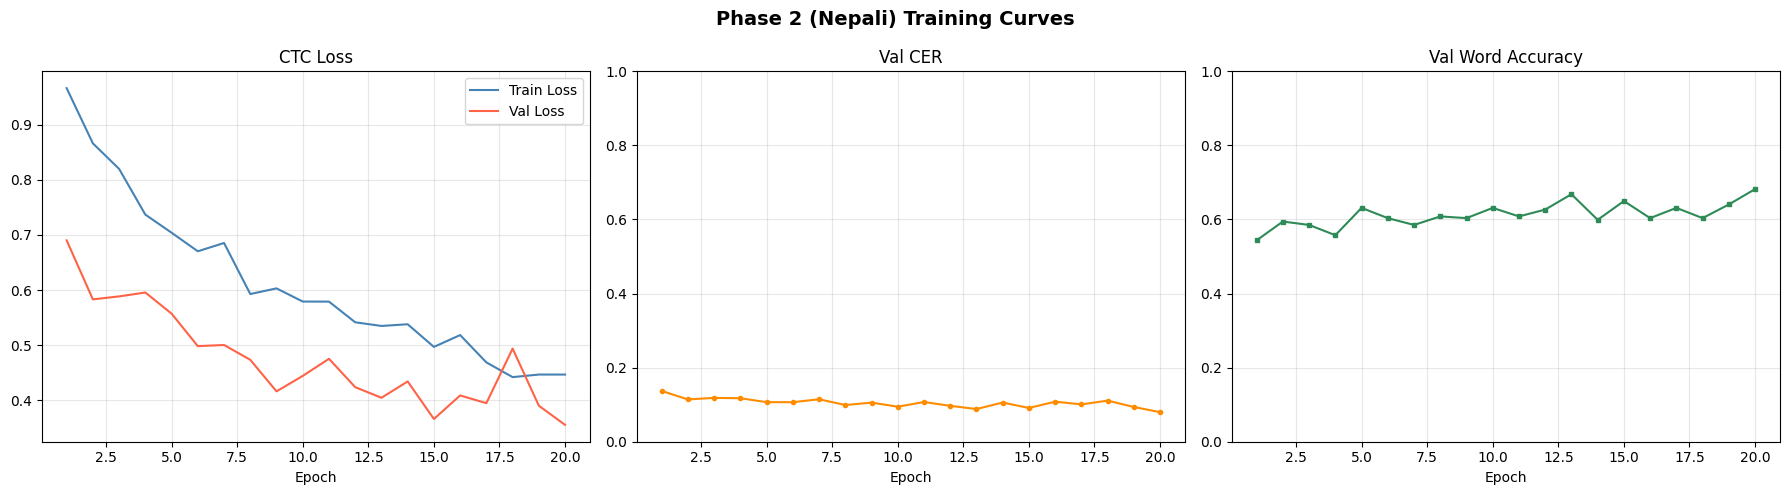

Saved: /kaggle/working/graphs/phase_2_(nepali)_curves.png


In [59]:
plot_training_curves(history_p2, phase='Phase 2 (Nepali)', save_dir=GRAPH_DIR)


### Phase 2 · Test Set Evaluation (Nepali)

In [60]:
# Load best Phase 2 weights
early_stop_p2.load_best(model_p2)

# Resample test set one final time (deterministic for reporting — fix seed)
random.seed(0); ds_n_test.resample()

te2_loss, te2_cer, te2_wacc, te2_preds, te2_targets = run_epoch(
    model_p2, dl_n_test, is_train=False)

print("=" * 50)
print("PHASE 2 — NEPALI TEST RESULTS")
print("=" * 50)
print(f"  CTC Loss           : {te2_loss:.4f}")
print(f"  CER                : {te2_cer:.4f}  ({te2_cer*100:.2f}%)")
print(f"  Word Accuracy      : {te2_wacc:.4f}  ({te2_wacc*100:.2f}%)")
print(f"  WER                : {1-te2_wacc:.4f}  ({(1-te2_wacc)*100:.2f}%)")
print("=" * 50)
print(f"\n  ▲ Improvement over Phase 1 baseline: +{(te2_wacc - p1_nep_wacc)*100:.2f}% word accuracy")

print("\nSample predictions (first 10):")
print(f"{'Target':<20} {'Predicted':<20} {'Match'}")
print("-" * 50)
for tgt, pred in list(zip(te2_targets, te2_preds))[:10]:
    print(f"{tgt:<20} {pred:<20} {'✓' if tgt==pred else '✗'}")


  Loaded best checkpoint: /kaggle/working/checkpoints/phase2/phase2_BEST.pth  (epoch 20, val_loss=0.3555)
PHASE 2 — NEPALI TEST RESULTS
  CTC Loss           : 0.2749
  CER                : 0.0671  (6.71%)
  Word Accuracy      : 0.6992  (69.92%)
  WER                : 0.3008  (30.08%)

  ▲ Improvement over Phase 1 baseline: +22.76% word accuracy

Sample predictions (first 10):
Target               Predicted            Match
--------------------------------------------------
म‌ंडल                मंडल                 ✗
सैयद                 सेयद                 ✗
श्रीकुमार            श्रीकुमार            ✓
सौराग्य              सौराम्य              ✗
प्रकाश               प्रलाश               ✗
चित्र                चित्र                ✓
नानी                 नानी                 ✓
डाल्मीया             डाल्मीया             ✓
तुलाधर               तुलाधर               ✓
समीप                 समीप                 ✓


### Phase 2 · Comparison Chart & Confusion Matrix

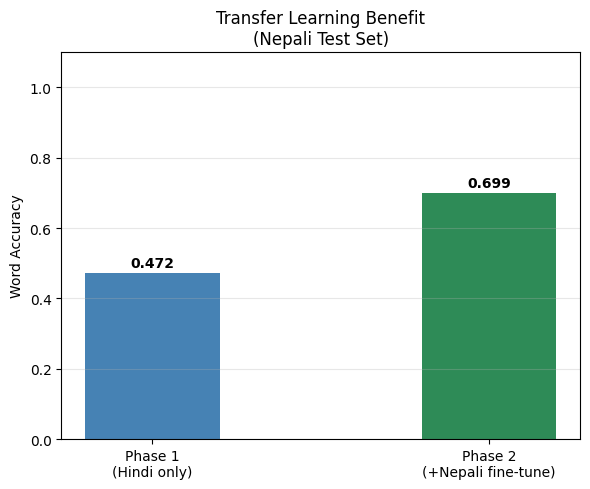

Saved: /kaggle/working/graphs/phase_comparison.png


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2306 (\N{DEVANAGARI SIGN ANUSVARA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Matplotlib currently does not support Devanagari natively.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2325 (\N{DEVANAGARI LETTER KA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2327 (\N{DEVANAGARI LETTER GA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2330 (\N{DEVANAGARI LETTER CA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2336 (\N{DEVANAGARI LETTER TTHA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/

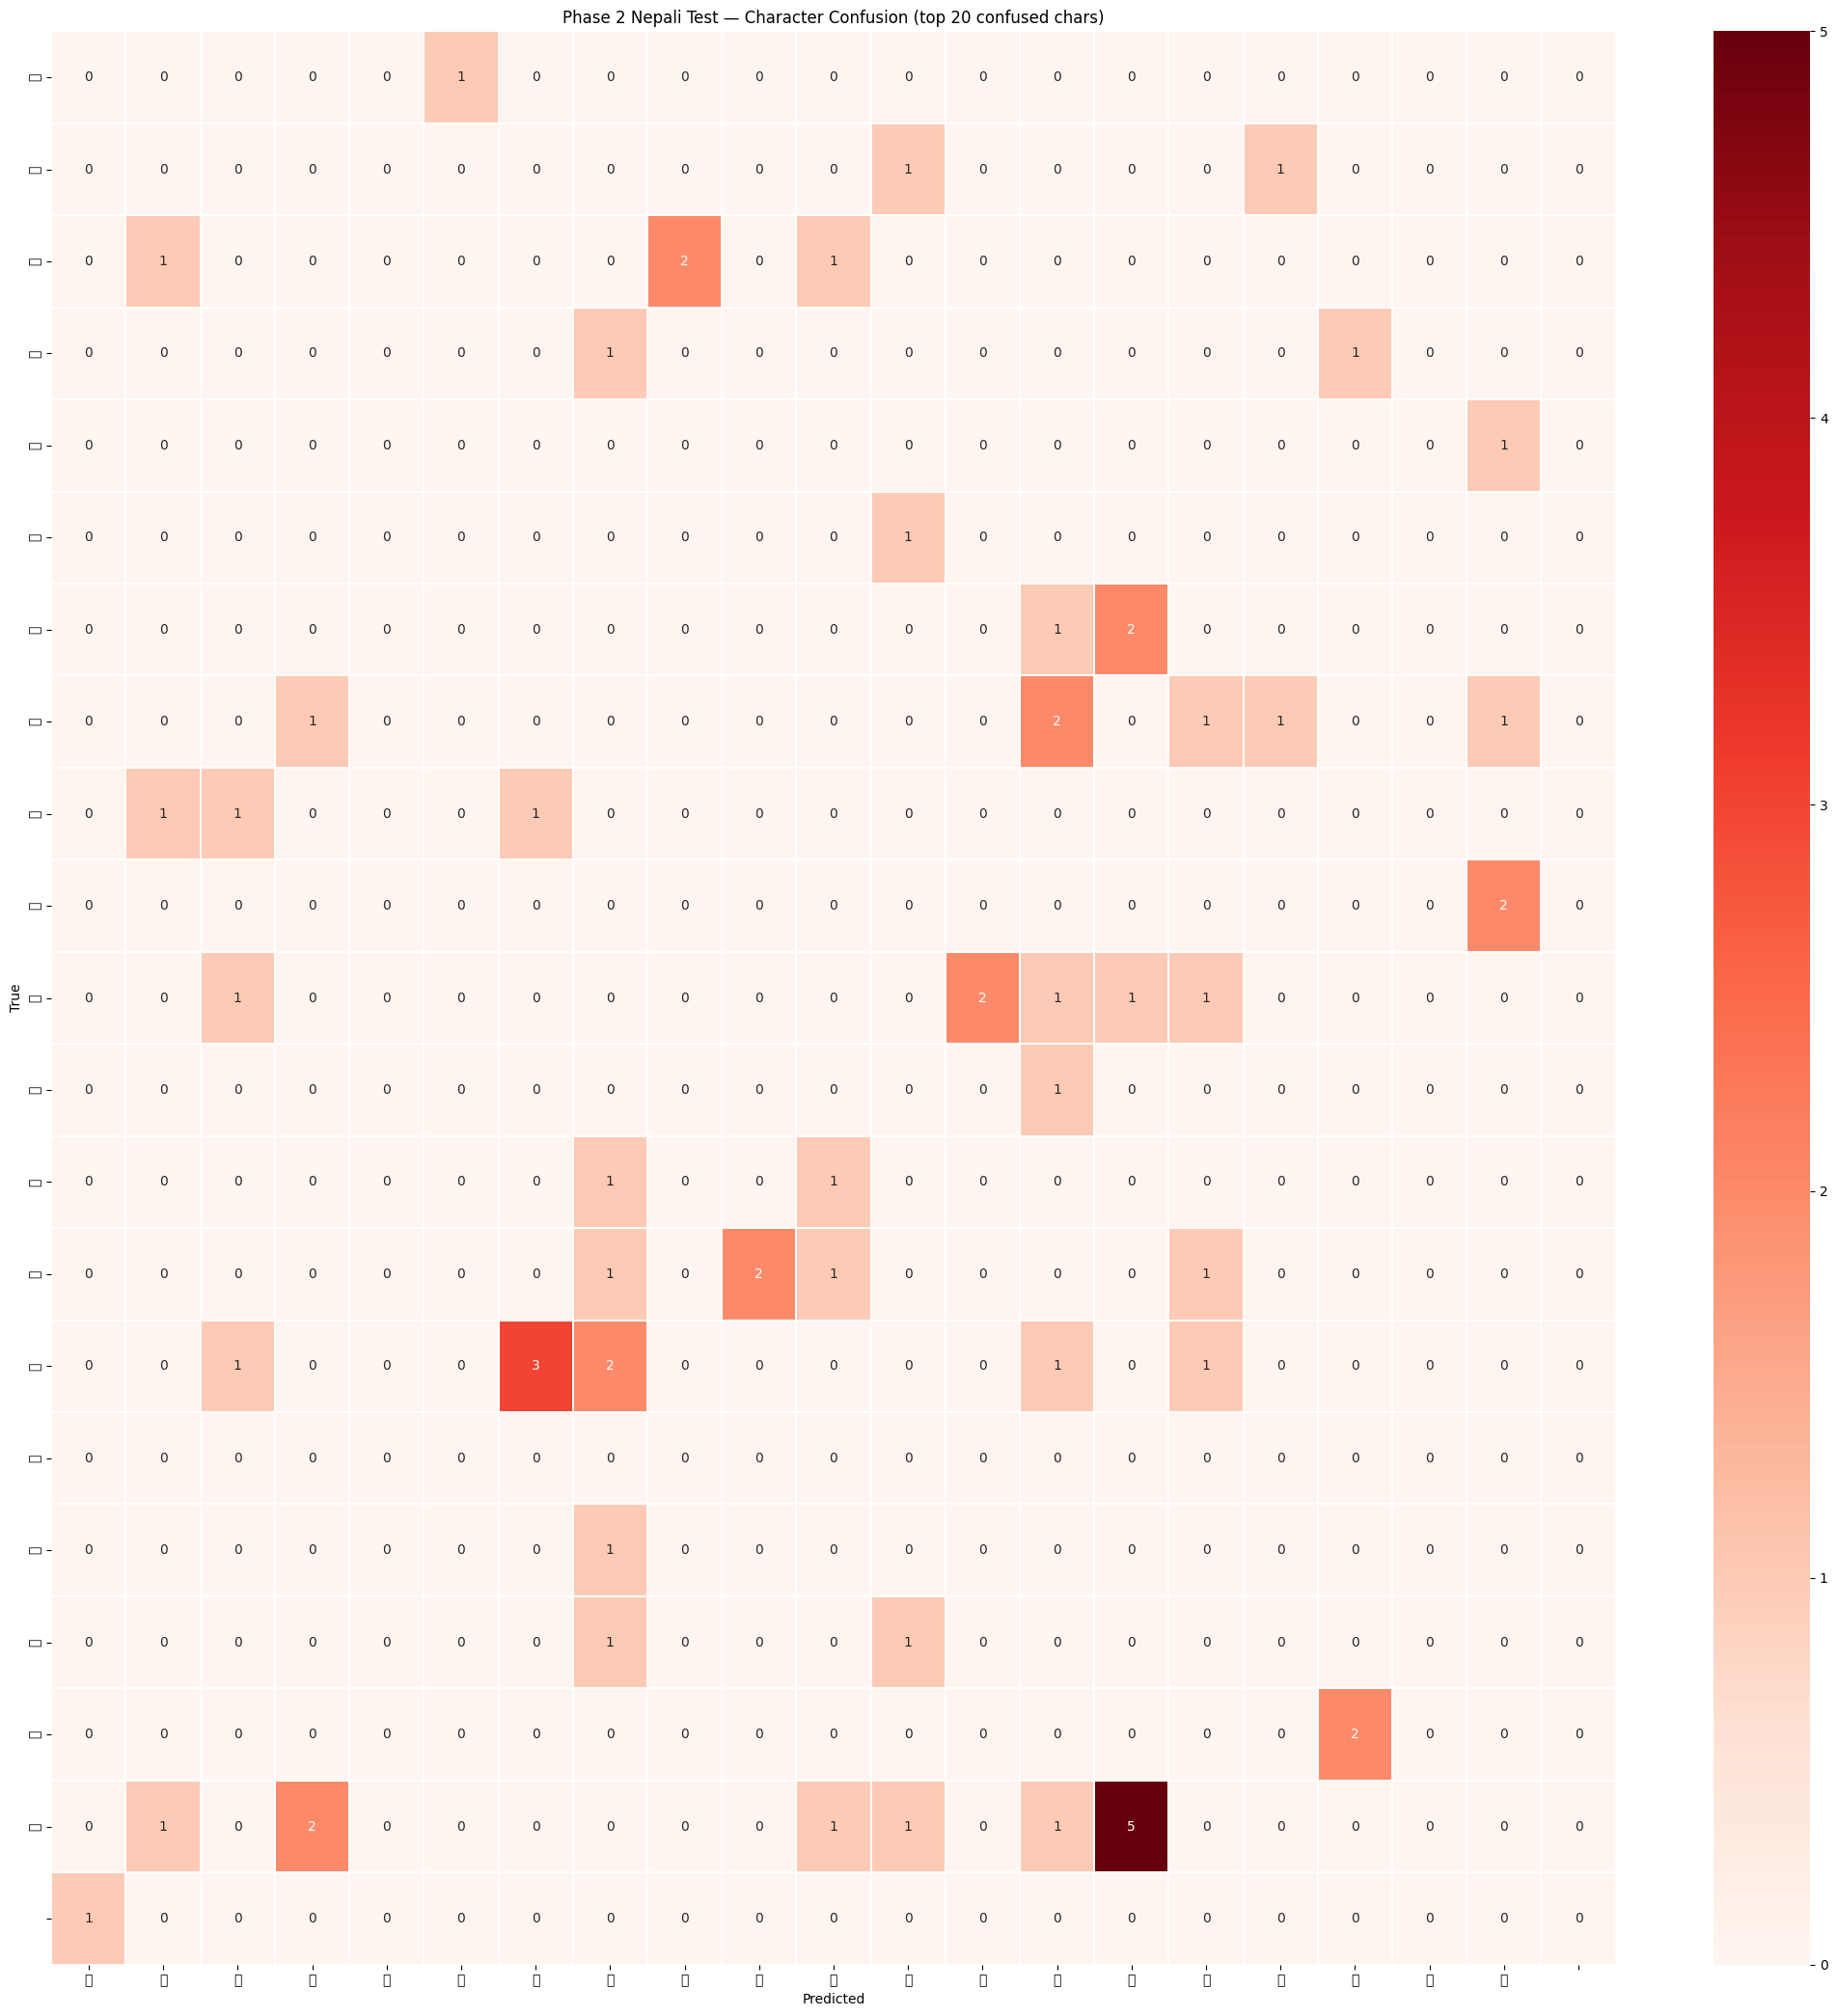

Saved: /kaggle/working/graphs/phase_2_nepali_test_confusion.png


In [61]:
# G7 — Transfer learning comparison bar chart
plot_phase_comparison(p1_nep_wacc, te2_wacc, save_dir=GRAPH_DIR)

# G8 — Character confusion matrix on Nepali test set
plot_confusion_matrix(te2_preds, te2_targets, save_dir=GRAPH_DIR,
                      title='Phase 2 Nepali Test', top_n=20)


---
# ═══════════════════════════════════════════════════════════
# PHASE 3 — NLP Postprocessor
# ═══════════════════════════════════════════════════════════

**Objective:** Correct CRNN output strings using Levenshtein distance search over a known Nepali vocabulary (names, surnames, districts). This handles character-level OCR errors that are phonetically or visually close.

**Logic:**
1. If output exactly matches a vocab entry → pass through
2. If edit distance ≤ 2 to any vocab entry → return the closest match
3. If field type is known (name/district) → constrain search space
4. If no match within distance 2 → return raw CRNN output unchanged


In [63]:
import os
for root, dirs, files in os.walk('/kaggle/input/datasets/kritakhere/nepali-names-shernames-districts/'):
    for f in files:
        print(os.path.join(root, f))

/kaggle/input/datasets/kritakhere/nepali-names-shernames-districts/vocab.json


In [65]:
VOCAB_PATH = '/kaggle/input/datasets/kritakhere/nepali-names-shernames-districts/vocab.json'

In [66]:
# ── Load vocab.json ───────────────────────────────────────────────────────────
with open(VOCAB_PATH, 'r', encoding='utf-8') as f:
    raw_vocab = json.load(f)

# Expected structure: {"first_names": [...], "last_names": [...], "districts": [...]}
# Adapt key names if your vocab.json uses different keys
first_names = raw_vocab.get('first_names', raw_vocab.get('names', []))
last_names  = raw_vocab.get('last_names',  raw_vocab.get('surnames', []))
districts   = raw_vocab.get('districts', [])

all_vocab_entries  = set(first_names + last_names + districts)
name_entries       = set(first_names + last_names)
district_entries   = set(districts)

print(f"Vocab loaded  →  first names: {len(first_names)}  |  last names: {len(last_names)}  |  districts: {len(districts)}")
print(f"Total unique entries: {len(all_vocab_entries)}")


Vocab loaded  →  first names: 789  |  last names: 485  |  districts: 79
Total unique entries: 1350


In [67]:
def nlp_postprocess(raw_text: str, field_type: str = 'auto',
                    max_edit_dist: int = 2) -> tuple:
    """
    Correct raw CRNN output against Nepali vocabulary.

    Parameters
    ----------
    raw_text   : raw decoded string from CRNN
    field_type : 'name' | 'district' | 'auto'
    max_edit_dist : maximum Levenshtein distance to accept a correction

    Returns
    -------
    (corrected_text, was_corrected: bool, edit_distance: int)
    """
    raw_text = raw_text.strip()
    if not raw_text:
        return raw_text, False, 0

    # Select search space
    if field_type == 'district':
        search_space = district_entries
    elif field_type == 'name':
        search_space = name_entries
    else:
        search_space = all_vocab_entries

    # Exact match → return immediately
    if raw_text in search_space:
        return raw_text, False, 0

    # Levenshtein search
    best_match, best_dist = None, max_edit_dist + 1
    for candidate in search_space:
        d = Levenshtein.distance(raw_text, candidate)
        if d < best_dist:
            best_dist  = d
            best_match = candidate

    if best_dist <= max_edit_dist and best_match is not None:
        return best_match, True, best_dist
    else:
        return raw_text, False, -1   # -1 = no match within threshold


# ── Test postprocessor on Phase 2 predictions ─────────────────────────────────
print("\nNLP Postprocessor — evaluation on Nepali test predictions:")
print(f"{'Raw CRNN':<20} {'Corrected':<20} {'Target':<20} {'∆'}")
print("-" * 70)

corrected_preds = []
n_corrected = 0
for raw, tgt in zip(te2_preds, te2_targets):
    corrected, was_fixed, dist = nlp_postprocess(raw, field_type='auto')
    corrected_preds.append(corrected)
    if was_fixed: n_corrected += 1

# Show first 15 that were actually corrected
shown = 0
for raw, corr, tgt in zip(te2_preds, corrected_preds, te2_targets):
    if raw != corr:
        delta = '✓' if corr == tgt else ('≈' if corr != raw else '✗')
        print(f"{raw:<20} {corr:<20} {tgt:<20} {delta}")
        shown += 1
        if shown >= 15: break

print(f"\nCorrected {n_corrected} / {len(te2_preds)} predictions ({n_corrected/len(te2_preds)*100:.1f}%)")

# Accuracy after postprocessing
post_wacc = compute_word_accuracy(corrected_preds, te2_targets)
post_cer  = compute_cer(corrected_preds, te2_targets)
print(f"\nAfter NLP postprocessing:")
print(f"  Word Accuracy : {post_wacc:.4f}  (was {te2_wacc:.4f}  |  Δ = {(post_wacc-te2_wacc)*100:+.2f}%)")
print(f"  CER           : {post_cer:.4f}   (was {te2_cer:.4f})")



NLP Postprocessor — evaluation on Nepali test predictions:
Raw CRNN             Corrected            Target               ∆
----------------------------------------------------------------------
सेयद                 सैयद                 सैयद                 ✓
सौराम्य              सौराग्य              सौराग्य              ✓
प्रलाश               प्रकाश               प्रकाश               ✓
सिगरनी               सिमरानी              सिमरानी              ✓
पा्क                 पाठक                 पाठक                 ✓
सनुवार               सुनुवार              सुनुवार              ✓
रशिमता               रमिता                एश्मिता              ≈
डोयी                 डोटी                 डोटी                 ✓
ह्द्य                बैद्य                हृदय                 ≈
लायिनद्रा            लायिन्द्रा           लायिन्द्रा           ✓
रामिका               राधिका               राष्मिका             ≈
रिनकु                रिन्कु               रिन्कु               ✓
पनेर                 पने

---
# Final Results Summary


In [68]:
print("=" * 60)
print("FINAL RESULTS SUMMARY")
print("=" * 60)
print(f"\n  Phase 1 — Hindi Handwriting Test")
print(f"    Word Accuracy : {te_wacc:.4f}  ({te_wacc*100:.2f}%)")
print(f"    CER           : {te_cer:.4f}  ({te_cer*100:.2f}%)")
print(f"\n  Phase 2 — Nepali Font Fine-tune Test (before NLP)")
print(f"    Word Accuracy : {te2_wacc:.4f}  ({te2_wacc*100:.2f}%)")
print(f"    CER           : {te2_cer:.4f}  ({te2_cer*100:.2f}%)")
print(f"    Δ vs P1 base  : {(te2_wacc - p1_nep_wacc)*100:+.2f}% word accuracy")
print(f"\n  Phase 3 — After NLP Postprocessing")
print(f"    Word Accuracy : {post_wacc:.4f}  ({post_wacc*100:.2f}%)")
print(f"    CER           : {post_cer:.4f}  ({post_cer*100:.2f}%)")
print(f"    Δ vs P2       : {(post_wacc-te2_wacc)*100:+.2f}% word accuracy")
print("=" * 60)
print(f"\nCheckpoints saved in:")
print(f"  {CKPT_P1}")
print(f"  {CKPT_P2}")
print(f"\nGraphs saved in: {GRAPH_DIR}")


FINAL RESULTS SUMMARY

  Phase 1 — Hindi Handwriting Test
    Word Accuracy : 0.6731  (67.31%)
    CER           : 0.0899  (8.99%)

  Phase 2 — Nepali Font Fine-tune Test (before NLP)
    Word Accuracy : 0.6992  (69.92%)
    CER           : 0.0671  (6.71%)
    Δ vs P1 base  : +22.76% word accuracy

  Phase 3 — After NLP Postprocessing
    Word Accuracy : 0.9187  (91.87%)
    CER           : 0.0349  (3.49%)
    Δ vs P2       : +21.95% word accuracy

Checkpoints saved in:
  /kaggle/working/checkpoints/phase1
  /kaggle/working/checkpoints/phase2

Graphs saved in: /kaggle/working/graphs
